**1. Load Lib**

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from wordcloud import WordCloud

**2. Load Data**

In [53]:
# Load dataset
df = pd.read_csv('Stress.csv')
df.head()

,subreddit,post_id,sentence_range,text,label,confidence,social_timestamp
0,ptsd,8601tu,"(15, 20)","He said he had not felt that way before, sugge...",1,0.8,1521614353
1,assistance,8lbrx9,"(0, 5)","Hey there r/assistance, Not sure if this is th...",0,1.0,1527009817
2,ptsd,9ch1zh,"(15, 20)",My mom then hit me with the newspaper and it s...,1,0.8,1535935605
3,relationships,7rorpp,"[5, 10]","until i met my new boyfriend, he is amazing, h...",1,0.6,1516429555
4,survivorsofabuse,9p2gbc,"[0, 5]",October is Domestic Violence Awareness Month a...,1,0.8,1539809005


**3. Pre-Processing Data**

In [54]:
# Handling missing values
df = df.dropna()
print("Missing values handled.")

# Data cleaning: removing unwanted characters, numbers, and symbols
import re
def clean_text(text):
    text = re.sub(r'[^A-Za-z\s]', '', text)
    text = text.lower()
    return text

df['text'] = df['text'].apply(clean_text)
print("Data cleaning completed.")
print(df.head())

Missing values handled.
Data cleaning completed.
          subreddit post_id sentence_range  \
0              ptsd  8601tu       (15, 20)   
1        assistance  8lbrx9         (0, 5)   
2              ptsd  9ch1zh       (15, 20)   
3     relationships  7rorpp        [5, 10]   
4  survivorsofabuse  9p2gbc         [0, 5]   

                                                text  label  confidence  \
0  he said he had not felt that way before sugget...      1         0.8   
1  hey there rassistance not sure if this is the ...      0         1.0   
2  my mom then hit me with the newspaper and it s...      1         0.8   
3  until i met my new boyfriend he is amazing he ...      1         0.6   
4  october is domestic violence awareness month a...      1         0.8   

   social_timestamp  
0        1521614353  
1        1527009817  
2        1535935605  
3        1516429555  
4        1539809005  


**4. Visualisasi Data**

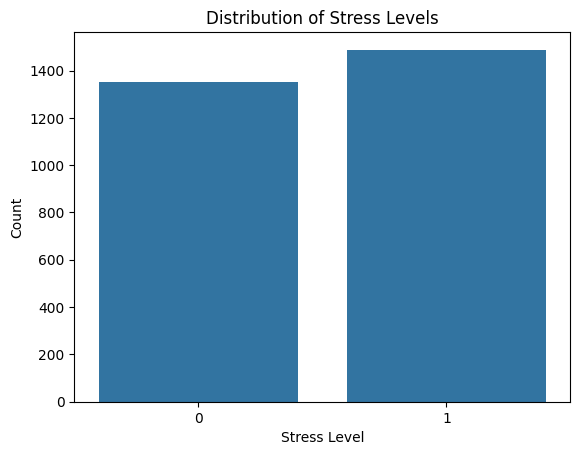

In [55]:
# Visualize distribution of labels
sns.countplot(x='label', data=df)
plt.title('Distribution of Stress Levels')
plt.xlabel('Stress Level')
plt.ylabel('Count')
plt.show()

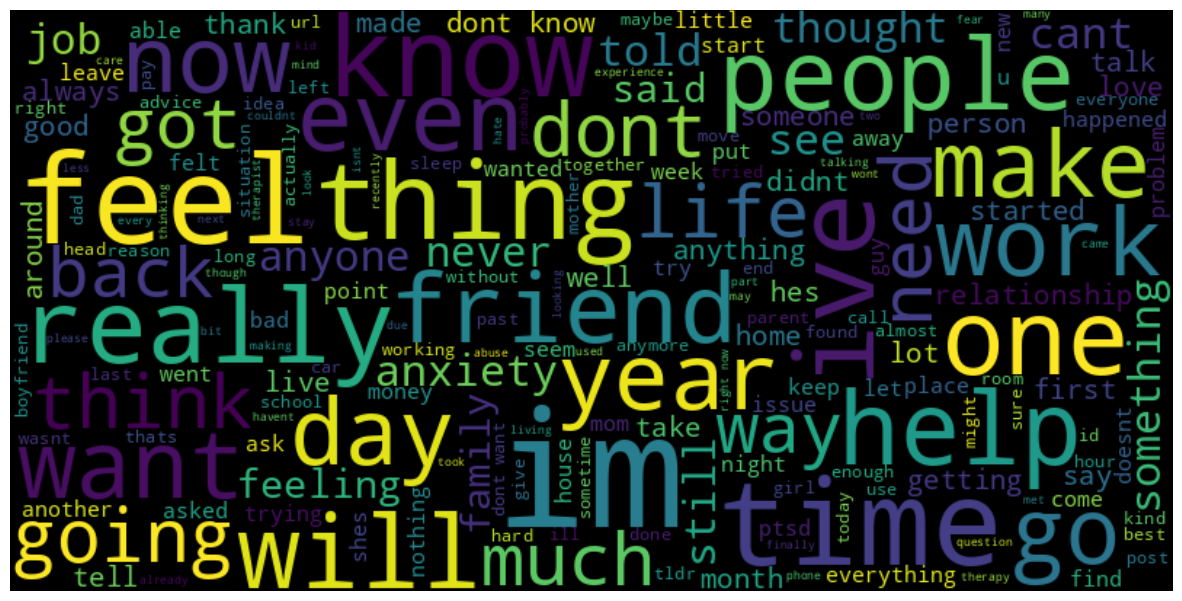

In [56]:
# Gabungkan semua kata dalam satu string
all_words = ' '.join(df['text'])  # Sesuaikan dengan nama kolom yang tepat

# Membuat WordCloud
wordcloud = WordCloud(width=800, height=400, random_state=21, max_font_size=110).generate(all_words)

# Menampilkan WordCloud
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

**5. Pemodelan Data**

In [57]:
# Feature extraction using TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['text']).toarray()
y = df['label']
print("Feature extraction completed.")

Feature extraction completed.


In [58]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data split into training and testing sets.")

Data split into training and testing sets.


In [59]:
# Pemodelan learning algoritma
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

**6. Menguji/Mengevaluasi Data**

In [60]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 74.30%


Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.72      0.72       263
           1       0.76      0.76      0.76       305

    accuracy                           0.74       568
   macro avg       0.74      0.74      0.74       568
weighted avg       0.74      0.74      0.74       568



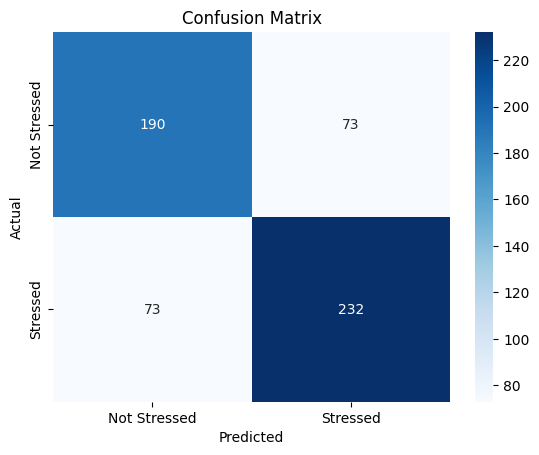

Model evaluation completed.


In [61]:
# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Stressed', 'Stressed'], yticklabels=['Not Stressed', 'Stressed'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("Model evaluation completed.")

In [62]:
# Fungsi untuk memprediksi tingkat stres dari teks baru
def predict_stress(text):
    processed_text = clean_text(text)  # Preprocessing teks baru
    vectorized_text = vectorizer.transform([processed_text])  # Mengubah teks menjadi vektor TF-IDF
    prediction = model.predict(vectorized_text)  # Melakukan prediksi menggunakan model
    return prediction[0]  # Mengembalikan prediksi tingkat stres (0 atau 1)

# Contoh pengujian dengan input baru
new_texts = [
    "I feel completely exhausted and overwhelmed by work",
    "I had a great day and I feel relaxed",
    "The constant deadlines are making me anxious"
]

for text in new_texts:
    stress_level = predict_stress(text)
    print(f"Teks: {text}\nPrediksi Level Stres: {stress_level}\n")


Teks: I feel completely exhausted and overwhelmed by work
Prediksi Level Stres: 1

Teks: I had a great day and I feel relaxed
Prediksi Level Stres: 0

Teks: The constant deadlines are making me anxious
Prediksi Level Stres: 1

